# Simulasi Backpropagation: Dataset XOR dengan 2 Hidden Neuron

**Mata Kuliah:** Kecerdasan Buatan & Robotika  
**Topik:** Simulasi Backpropagation Menggunakan Dataset XOR  
**Metode:** Backpropagation dengan Fungsi Aktivasi Sigmoid  
**Arsitektur:** 2 Input -> 2 Hidden -> 1 Output

---

## Tujuan Notebook

Notebook ini menjelaskan cara kerja algoritma **backpropagation** secara bertahap untuk menyelesaikan masalah **XOR (Exclusive OR)**. Pembahasan dimulai dari pembentukan dataset, inisialisasi bobot, forward pass, perhitungan error, backward pass, update bobot, hingga evaluasi model setelah proses training.

Setiap perhitungan dibuat eksplisit agar proses pembelajaran neural network dapat diikuti, diuji ulang, dan diverifikasi secara manual.


---

## 0. Import Library

Notebook ini menggunakan dua library utama:

- `numpy` untuk operasi numerik, array, matrix, bobot, bias, dan perhitungan forward/backward pass.
- `matplotlib` untuk visualisasi fungsi aktivasi, error training, dan hasil eksperimen.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Supaya grafik tampil rapi di dalam notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 11

print("Library berhasil di-import!")

Library berhasil di-import!


---

## 1. Dataset XOR

XOR (Exclusive OR) adalah operasi logika dengan aturan berikut:

- Output bernilai **1** jika kedua input **berbeda**.
- Output bernilai **0** jika kedua input **sama**.

| X1 | X2 | Target (Y) |
|:--:|:--:|:----------:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

XOR menarik untuk dipelajari karena datanya tidak **linearly separable**. Artinya, pola XOR tidak dapat dipisahkan hanya dengan satu garis lurus. Karena itu, jaringan membutuhkan **hidden layer** untuk mempelajari representasi non-linear.


In [2]:
# Dataset XOR
# Setiap baris = satu data: [X1, X2]
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Target output untuk tiap data
y = np.array([[0], [1], [1], [0]])

print("Dataset XOR:")
print("-" * 30)
print(f"{'X1':>4} {'X2':>4} {'Target':>8}")
print("-" * 30)
for i in range(len(X)):
    print(f"{X[i][0]:>4} {X[i][1]:>4} {y[i][0]:>8}")
print("-" * 30)
print(f"Total data: {len(X)} baris")

Dataset XOR:
------------------------------
  X1   X2   Target
------------------------------
   0    0        0
   0    1        1
   1    0        1
   1    1        0
------------------------------
Total data: 4 baris


---

## 2. Arsitektur Jaringan

Jaringan yang digunakan memiliki struktur **2-2-1**:

<img src="images/jaringan.png" width="500" alt="Arsitektur neural network untuk dataset XOR">

Komponen utama jaringan:

- **Input layer:** menerima dua fitur input, yaitu `X1` dan `X2`.
- **Hidden layer:** terdiri dari dua neuron untuk mempelajari pola non-linear.
- **Output layer:** menghasilkan prediksi akhir dalam rentang 0 sampai 1.
- **Weights:** menentukan kekuatan koneksi antar neuron.
- **Bias:** membantu neuron menggeser fungsi aktivasi agar model lebih fleksibel.
- **Sigmoid activation:** mengubah net input menjadi nilai antara 0 dan 1.


---

## 3. Fungsi Aktivasi Sigmoid

Fungsi sigmoid digunakan pada neuron hidden layer dan output layer untuk mengubah nilai net input menjadi output dalam rentang 0 sampai 1.

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Turunan sigmoid dibutuhkan pada proses backward pass untuk menghitung gradien:

$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))
$$

Jika nilai output sigmoid sudah diketahui, turunannya dapat ditulis sebagai:

$$
\sigma'(output) = output \cdot (1 - output)
$$


In [3]:
def sigmoid(x):
    """Fungsi aktivasi sigmoid: mengubah nilai apapun menjadi rentang 0-1"""
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(output):
    """
    Turunan sigmoid — dipakai saat backward pass.
    Input: output sigmoid yang sudah dihitung (bukan nilai net-nya lagi).
    Rumus: output * (1 - output)
    """
    return output * (1 - output)


# --- Verifikasi fungsi ---
print("Verifikasi fungsi sigmoid:")
print(f"  sigmoid(0)   = {sigmoid(0):.4f}   (harusnya 0.5000)")
print(f"  sigmoid(1)   = {sigmoid(1):.4f}   (harusnya 0.7311)")
print(f"  sigmoid(-1)  = {sigmoid(-1):.4f}   (harusnya 0.2689)")
print()
print("Verifikasi turunan sigmoid:")
s = sigmoid(0)
print(f"  sigmoid_derivative(sigmoid(0)) = {sigmoid_derivative(s):.4f}  (harusnya 0.2500)")

Verifikasi fungsi sigmoid:
  sigmoid(0)   = 0.5000   (harusnya 0.5000)
  sigmoid(1)   = 0.7311   (harusnya 0.7311)
  sigmoid(-1)  = 0.2689   (harusnya 0.2689)

Verifikasi turunan sigmoid:
  sigmoid_derivative(sigmoid(0)) = 0.2500  (harusnya 0.2500)


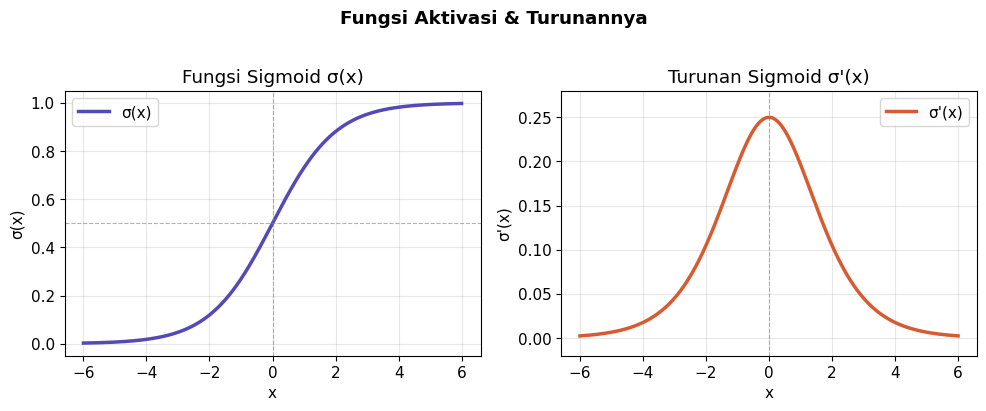

Catatan: turunan sigmoid mencapai maksimum 0.25 di x=0


In [4]:
# Visualisasi kurva sigmoid
x_vals = np.linspace(-6, 6, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Kurva sigmoid
ax1.plot(x_vals, sigmoid(x_vals), color='#534AB7', linewidth=2.5, label='σ(x)')
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.set_title('Fungsi Sigmoid σ(x)')
ax1.set_xlabel('x')
ax1.set_ylabel('σ(x)')
ax1.set_ylim(-0.05, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Kurva turunan
s_vals = sigmoid(x_vals)
ax2.plot(x_vals, sigmoid_derivative(s_vals), color='#D85A30', linewidth=2.5, label="σ'(x)")
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_title("Turunan Sigmoid σ'(x)")
ax2.set_xlabel('x')
ax2.set_ylabel("σ'(x)")
ax2.set_ylim(-0.02, 0.28)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Fungsi Aktivasi & Turunannya', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Catatan: turunan sigmoid mencapai maksimum 0.25 di x=0")

---

## 4. Inisialisasi Bobot dan Bias

Bobot awal diinisialisasi dengan nilai acak kecil pada rentang -1 sampai 1. Inisialisasi acak diperlukan agar setiap neuron dapat belajar pola yang berbeda.

Notebook ini menggunakan `np.random.seed(42)` agar hasil training **reproducible**. Dengan seed yang sama, bobot awal yang dihasilkan akan konsisten setiap kali notebook dijalankan.


In [5]:
# Set seed supaya hasil selalu sama setiap dijalankan
np.random.seed(42)

# ── Bobot input → hidden (W1) ──────────────────────────────────────────────
# Shape: (2, 2) → 2 input, 2 hidden neuron
# W1[i][j] = bobot dari input ke-i ke hidden neuron ke-j
W1_demo = np.random.uniform(-1, 1, (2, 2))

# ── Bias hidden layer (b1) ────────────────────────────────────────────────
# Shape: (1, 2) → satu bias untuk setiap hidden neuron
b1_demo = np.zeros((1, 2))

# ── Bobot hidden → output (W2) ────────────────────────────────────────────
# Shape: (2, 1) → 2 hidden neuron, 1 output
W2_demo = np.random.uniform(-1, 1, (2, 1))

# ── Bias output layer (b2) ────────────────────────────────────────────────
# Shape: (1, 1) → satu bias untuk output neuron
b2_demo = np.zeros((1, 1))

# Learning rate — mengontrol seberapa besar perubahan bobot tiap update
learning_rate = 0.5

# --- Tampilkan nilai awal ---
print("=" * 45)
print("INISIALISASI BOBOT AWAL (untuk DEMO)")
print("=" * 45)
print(f"\nW1_demo (input → hidden), shape {W1_demo.shape}:")
print(f"  w_i1_h1 = {W1_demo[0][0]:.4f}  |  w_i1_h2 = {W1_demo[0][1]:.4f}")
print(f"  w_i2_h1 = {W1_demo[1][0]:.4f}  |  w_i2_h2 = {W1_demo[1][1]:.4f}")

print(f"\nb1_demo (bias hidden), shape {b1_demo.shape}:")
print(f"  b_h1 = {b1_demo[0][0]:.4f}  |  b_h2 = {b1_demo[0][1]:.4f}")

print(f"\nW2_demo (hidden → output), shape {W2_demo.shape}:")
print(f"  w_h1_o = {W2_demo[0][0]:.4f}")
print(f"  w_h2_o = {W2_demo[1][0]:.4f}")

print(f"\nb2_demo (bias output), shape {b2_demo.shape}:")
print(f"  b_o = {b2_demo[0][0]:.4f}")

print(f"\nLearning rate (η) = {learning_rate}")

INISIALISASI BOBOT AWAL (untuk DEMO)

W1_demo (input → hidden), shape (2, 2):
  w_i1_h1 = -0.2509  |  w_i1_h2 = 0.9014
  w_i2_h1 = 0.4640  |  w_i2_h2 = 0.1973

b1_demo (bias hidden), shape (1, 2):
  b_h1 = 0.0000  |  b_h2 = 0.0000

W2_demo (hidden → output), shape (2, 1):
  w_h1_o = -0.6880
  w_h2_o = -0.6880

b2_demo (bias output), shape (1, 1):
  b_o = 0.0000

Learning rate (η) = 0.5


---

## 5. Forward Pass

Forward pass adalah proses menghitung output jaringan dari input layer menuju output layer.

Tahapan forward pass:

1. Hitung net input hidden layer: `net_H = X @ W1 + b1`
2. Hitung output hidden layer: `out_H = sigmoid(net_H)`
3. Hitung net input output layer: `net_Y = out_H @ W2 + b2`
4. Hitung output akhir: `out_Y = sigmoid(net_Y)`

Hasil `out_Y` kemudian dibandingkan dengan target untuk menghitung error.


In [6]:
def forward_pass(X, W1, b1, W2, b2):
    """
    Menghitung output jaringan dari input ke output.

    Returns semua nilai intermediate supaya bisa dipakai
    saat backward pass nanti.
    """
    # --- Layer 1: Input → Hidden ---
    # net_H: hasil perkalian input dengan bobot, ditambah bias
    net_H = np.dot(X, W1) + b1
    out_H = sigmoid(net_H)          # aktivasi sigmoid

    # --- Layer 2: Hidden → Output ---
    net_Y = np.dot(out_H, W2) + b2
    out_Y = sigmoid(net_Y)          # aktivasi sigmoid

    return out_H, out_Y


# --- Demo forward pass untuk 1 data (X1=0, X2=1) ---
X_sample = np.array([[0, 1]])       # ambil data ke-2
target    = np.array([[1]])

out_H, out_Y = forward_pass(X_sample, W1_demo, b1_demo, W2_demo, b2_demo)

print("=" * 45)
print("DEMO FORWARD PASS (menggunakan bobot demo)")
print(f"Input   : X1={X_sample[0][0]}, X2={X_sample[0][1]}")
print(f"Target  : {target[0][0]}")
print("=" * 45)

print(f"\n[Hidden Layer]")
net_H_demo = np.dot(X_sample, W1_demo) + b1_demo
print(f"  net_H1 = {net_H_demo[0][0]:.4f}  →  out_H1 = {out_H[0][0]:.4f}")
print(f"  net_H2 = {net_H_demo[0][1]:.4f}  →  out_H2 = {out_H[0][1]:.4f}")

print(f"\n[Output Layer]")
net_Y_demo = np.dot(out_H, W2_demo) + b2_demo
print(f"  net_Y  = {net_Y_demo[0][0]:.4f}  →  out_Y  = {out_Y[0][0]:.4f}")

error = 0.5 * (target - out_Y) ** 2
print(f"\n[Error]")
print(f"  E = ½ × ({target[0][0]} - {out_Y[0][0]:.4f})²  =  {error[0][0]:.6f}")

DEMO FORWARD PASS (menggunakan bobot demo)
Input   : X1=0, X2=1
Target  : 1

[Hidden Layer]
  net_H1 = 0.4640  →  out_H1 = 0.6140
  net_H2 = 0.1973  →  out_H2 = 0.5492

[Output Layer]
  net_Y  = -0.8002  →  out_Y  = 0.3100

[Error]
  E = ½ × (1 - 0.3100)²  =  0.238064


In [7]:
print("\n" + "="*70)
print("PERHITUNGAN MANUAL: FORWARD PASS STEP-BY-STEP")
print("="*70)

print("\nDiketahui:")
print(f"  Input X = {X_sample[0]}")
print(f"  Target = {target[0][0]}")
print(f"\n  W1_demo =")
print(f"    [{W1_demo[0][0]:7.4f}  {W1_demo[0][1]:7.4f}]  (w_i1_h1, w_i1_h2)")
print(f"    [{W1_demo[1][0]:7.4f}  {W1_demo[1][1]:7.4f}]  (w_i2_h1, w_i2_h2)")
print(f"\n  b1_demo = [{b1_demo[0][0]:7.4f}  {b1_demo[0][1]:7.4f}]")
print(f"\n  W2_demo = [{W2_demo[0][0]:7.4f}]  (w_h1_o)")
print(f"            [{W2_demo[1][0]:7.4f}]  (w_h2_o)")
print(f"\n  b2_demo = [{b2_demo[0][0]:7.4f}]")

print("\n" + "-"*70)
print("STEP 1: Hitung net_H (linear combination input → hidden)")
print("-"*70)

net_H1_manual = X_sample[0][0] * W1_demo[0][0] + X_sample[0][1] * W1_demo[1][0] + b1_demo[0][0]
net_H2_manual = X_sample[0][0] * W1_demo[0][1] + X_sample[0][1] * W1_demo[1][1] + b1_demo[0][1]

print(f"\nnet_H1 = X1 × w_i1_h1 + X2 × w_i2_h1 + b_h1")
print(f"       = {X_sample[0][0]} × {W1_demo[0][0]:.4f} + {X_sample[0][1]} × {W1_demo[1][0]:.4f} + {b1_demo[0][0]:.4f}")
print(f"       = {X_sample[0][0] * W1_demo[0][0]:.4f} + {X_sample[0][1] * W1_demo[1][0]:.4f} + {b1_demo[0][0]:.4f}")
print(f"       = {net_H1_manual:.4f}")

print(f"\nnet_H2 = X1 × w_i1_h2 + X2 × w_i2_h2 + b_h2")
print(f"       = {X_sample[0][0]} × {W1_demo[0][1]:.4f} + {X_sample[0][1]} × {W1_demo[1][1]:.4f} + {b1_demo[0][1]:.4f}")
print(f"       = {X_sample[0][0] * W1_demo[0][1]:.4f} + {X_sample[0][1] * W1_demo[1][1]:.4f} + {b1_demo[0][1]:.4f}")
print(f"       = {net_H2_manual:.4f}")

print("\n" + "-"*70)
print("STEP 2: Hitung out_H = sigmoid(net_H)")
print("-"*70)

out_H1_manual = 1 / (1 + np.exp(-net_H1_manual))
out_H2_manual = 1 / (1 + np.exp(-net_H2_manual))

print(f"\nout_H1 = 1 / (1 + e^(-{net_H1_manual:.4f}))")
print(f"       = 1 / (1 + {np.exp(-net_H1_manual):.4f})")
print(f"       = {out_H1_manual:.4f}")

print(f"\nout_H2 = 1 / (1 + e^(-{net_H2_manual:.4f}))")
print(f"       = 1 / (1 + {np.exp(-net_H2_manual):.4f})")
print(f"       = {out_H2_manual:.4f}")

print("\n" + "-"*70)
print("STEP 3: Hitung net_Y (linear combination hidden → output)")
print("-"*70)

net_Y_manual = out_H1_manual * W2_demo[0][0] + out_H2_manual * W2_demo[1][0] + b2_demo[0][0]

print(f"\nnet_Y = out_H1 × w_h1_o + out_H2 × w_h2_o + b_o")
print(f"      = {out_H1_manual:.4f} × {W2_demo[0][0]:.4f} + {out_H2_manual:.4f} × {W2_demo[1][0]:.4f} + {b2_demo[0][0]:.4f}")
print(f"      = {out_H1_manual * W2_demo[0][0]:.4f} + {out_H2_manual * W2_demo[1][0]:.4f} + {b2_demo[0][0]:.4f}")
print(f"      = {net_Y_manual:.4f}")

print("\n" + "-"*70)
print("STEP 4: Hitung out_Y = sigmoid(net_Y)")
print("-"*70)

out_Y_manual = 1 / (1 + np.exp(-net_Y_manual))

print(f"\nout_Y = 1 / (1 + e^(-{net_Y_manual:.4f}))")
print(f"      = 1 / (1 + {np.exp(-net_Y_manual):.4f})")
print(f"      = {out_Y_manual:.4f}")

print("\n" + "-"*70)
print("STEP 5: Hitung Error")
print("-"*70)

error_manual = 0.5 * (target[0][0] - out_Y_manual) ** 2

print(f"\nE = ½ × (target - out_Y)²")
print(f"  = ½ × ({target[0][0]} - {out_Y_manual:.4f})²")
print(f"  = ½ × ({target[0][0] - out_Y_manual:.4f})²")
print(f"  = ½ × {(target[0][0] - out_Y_manual)**2:.6f}")
print(f"  = {error_manual:.6f}")

print("\n" + "="*70)
print("VERIFIKASI: Bandingkan dengan function output")
print("="*70)
print(f"\nManual calculation:")
print(f"  out_H = [{out_H1_manual:.4f}, {out_H2_manual:.4f}]")
print(f"  out_Y = {out_Y_manual:.4f}")
print(f"  Error = {error_manual:.6f}")

print(f"\nFunction output (forward_pass):")
print(f"  out_H = [{out_H[0][0]:.4f}, {out_H[0][1]:.4f}]")
print(f"  out_Y = {out_Y[0][0]:.4f}")
print(f"  Error = {error[0][0]:.6f}")

print(f"\nMatch? {np.allclose([out_H1_manual, out_H2_manual], out_H[0]) and np.allclose(out_Y_manual, out_Y[0][0])} ✓")
print("="*70 + "\n")


PERHITUNGAN MANUAL: FORWARD PASS STEP-BY-STEP

Diketahui:
  Input X = [0 1]
  Target = 1

  W1_demo =
    [-0.2509   0.9014]  (w_i1_h1, w_i1_h2)
    [ 0.4640   0.1973]  (w_i2_h1, w_i2_h2)

  b1_demo = [ 0.0000   0.0000]

  W2_demo = [-0.6880]  (w_h1_o)
            [-0.6880]  (w_h2_o)

  b2_demo = [ 0.0000]

----------------------------------------------------------------------
STEP 1: Hitung net_H (linear combination input → hidden)
----------------------------------------------------------------------

net_H1 = X1 × w_i1_h1 + X2 × w_i2_h1 + b_h1
       = 0 × -0.2509 + 1 × 0.4640 + 0.0000
       = -0.0000 + 0.4640 + 0.0000
       = 0.4640

net_H2 = X1 × w_i1_h2 + X2 × w_i2_h2 + b_h2
       = 0 × 0.9014 + 1 × 0.1973 + 0.0000
       = 0.0000 + 0.1973 + 0.0000
       = 0.1973

----------------------------------------------------------------------
STEP 2: Hitung out_H = sigmoid(net_H)
----------------------------------------------------------------------

out_H1 = 1 / (1 + e^(-0.4640))
  

---

## 6. Backward Pass

Backward pass menghitung kontribusi setiap bobot terhadap error, lalu menggunakan informasi tersebut untuk memperbarui bobot dan bias. Proses ini menggunakan prinsip **chain rule**.

### A. Delta Output Layer

$$
\delta_Y = (target - out_Y) \times out_Y \times (1 - out_Y)
$$

### B. Delta Hidden Layer

$$
\delta_H = (\delta_Y \cdot W2^T) \times out_H \times (1 - out_H)
$$

### C. Update Bobot dan Bias

$$
W = W + \eta \times input^T \cdot \delta
$$

$$
b = b + \eta \times \delta
$$

Keterangan: `eta` atau $\eta$ adalah learning rate, yaitu parameter yang mengatur besar langkah pembaruan bobot.


In [8]:
def backward_pass(X, out_H, out_Y, target, W1, b1, W2, b2, learning_rate):
    """
    Menghitung gradien dan memperbarui semua bobot + bias.

    Returns bobot yang sudah diperbarui.
    """
    # ── A. Delta output layer ──────────────────────────────────────────────
    # Seberapa besar error output dan seberapa sensitif neuron output
    error_output = target - out_Y
    delta_Y = error_output * sigmoid_derivative(out_Y)

    # ── B. Delta hidden layer ──────────────────────────────────────────────
    # Propagasi sinyal delta balik ke hidden layer
    error_hidden = np.dot(delta_Y, W2.T)
    delta_H = error_hidden * sigmoid_derivative(out_H)

    # ── C. Update bobot & bias ────────────────────────────────────────────
    W2 = W2 + learning_rate * np.dot(out_H.T, delta_Y)
    b2 = b2 + learning_rate * np.sum(delta_Y, axis=0, keepdims=True)

    W1 = W1 + learning_rate * np.dot(X.T, delta_H)
    b1 = b1 + learning_rate * np.sum(delta_H, axis=0, keepdims=True)

    return W1, b1, W2, b2


# ═════════════════════════════════════════════════════════════════════════════
# CATATAN PENTING (DEMO ONLY):
# Section ini adalah DEMONSTRASI backward pass pada satu sample data.
# Update bobot yang dihasilkan (W1_demo_updated, W2_demo_updated) hanya
# untuk tujuan edukasi. Training sebenarnya dilakukan di Section 7
# dengan inisialisasi dan bobot yang INDEPENDENT.
# ═════════════════════════════════════════════════════════════════════════════

# --- Demo backward pass (lanjutan dari forward pass demo di atas) ---
print("\n" + "=" * 45)
print("DEMO BACKWARD PASS (update bobot demo sekali)")
print(f"out_Y = {out_Y[0][0]:.4f}, target = {target[0][0]}")
print("=" * 45)

error_output = target - out_Y
delta_Y = error_output * sigmoid_derivative(out_Y)
error_hidden = np.dot(delta_Y, W2_demo.T)
delta_H = error_hidden * sigmoid_derivative(out_H)

print(f"\n[Delta Output]")
print(f"  error_output  = {target[0][0]} - {out_Y[0][0]:.4f} = {error_output[0][0]:.4f}")
print(f"  delta_Y       = {error_output[0][0]:.4f} × σ'({out_Y[0][0]:.4f})")
print(f"                = {error_output[0][0]:.4f} × {sigmoid_derivative(out_Y)[0][0]:.4f}")
print(f"                = {delta_Y[0][0]:.6f}")

print(f"\n[Delta Hidden]")
print(f"  delta_H1      = {delta_H[0][0]:.6f}")
print(f"  delta_H2      = {delta_H[0][1]:.6f}")

# Simpan bobot lama untuk perbandingan
W1_lama, W2_lama = W1_demo.copy(), W2_demo.copy()

W1_demo_updated, b1_demo_updated, W2_demo_updated, b2_demo_updated = backward_pass(
    X_sample, out_H, out_Y, target, W1_demo, b1_demo, W2_demo, b2_demo, learning_rate
)

print(f"\n[Update Bobot W2 (hidden → output)]")
for i in range(2):
    print(f"  w_h{i+1}_o: {W2_lama[i][0]:.4f}  →  {W2_demo_updated[i][0]:.4f}  (Δ = {W2_demo_updated[i][0]-W2_lama[i][0]:+.6f})")

print(f"\n[Update Bobot W1 (input → hidden)]")
for i in range(2):
    for j in range(2):
        print(f"  w_i{i+1}_h{j+1}: {W1_lama[i][j]:.4f}  →  {W1_demo_updated[i][j]:.4f}  (Δ = {W1_demo_updated[i][j]-W1_lama[i][j]:+.6f})")

print(f"\n💡 Catatan: Bobot di atas hanya untuk demo. Training sebenarnya di Section 7.")


DEMO BACKWARD PASS (update bobot demo sekali)
out_Y = 0.3100, target = 1

[Delta Output]
  error_output  = 1 - 0.3100 = 0.6900
  delta_Y       = 0.6900 × σ'(0.3100)
                = 0.6900 × 0.2139
                = 0.147590

[Delta Hidden]
  delta_H1      = -0.024065
  delta_H2      = -0.025140

[Update Bobot W2 (hidden → output)]
  w_h1_o: -0.6880  →  -0.6427  (Δ = +0.045307)
  w_h2_o: -0.6880  →  -0.6475  (Δ = +0.040526)

[Update Bobot W1 (input → hidden)]
  w_i1_h1: -0.2509  →  -0.2509  (Δ = +0.000000)
  w_i1_h2: 0.9014  →  0.9014  (Δ = +0.000000)
  w_i2_h1: 0.4640  →  0.4520  (Δ = -0.012033)
  w_i2_h2: 0.1973  →  0.1847  (Δ = -0.012570)

💡 Catatan: Bobot di atas hanya untuk demo. Training sebenarnya di Section 7.


In [9]:
print("\n" + "="*70)
print("PERHITUNGAN MANUAL: BACKWARD PASS STEP-BY-STEP")
print("="*70)

print("\nDari forward pass, kita sudah punya:")
print(f"  out_H1 = {out_H1_manual:.4f},  out_H2 = {out_H2_manual:.4f}")
print(f"  out_Y  = {out_Y_manual:.4f}")
print(f"  target = {target[0][0]}")

print("\n" + "-"*70)
print("TAHAP A: Hitung delta output layer (δ_Y)")
print("-"*70)

sigma_prime_Y = out_Y_manual * (1 - out_Y_manual)
delta_Y_manual = (target[0][0] - out_Y_manual) * sigma_prime_Y

print(f"\nσ'(out_Y) = out_Y × (1 - out_Y)")
print(f"          = {out_Y_manual:.4f} × (1 - {out_Y_manual:.4f})")
print(f"          = {out_Y_manual:.4f} × {1 - out_Y_manual:.4f}")
print(f"          = {sigma_prime_Y:.4f}")

print(f"\nerror_output = target - out_Y")
print(f"             = {target[0][0]} - {out_Y_manual:.4f}")
print(f"             = {target[0][0] - out_Y_manual:.4f}")

print(f"\nδ_Y = error_output × σ'(out_Y)")
print(f"    = {target[0][0] - out_Y_manual:.4f} × {sigma_prime_Y:.4f}")
print(f"    = {delta_Y_manual:.4f}")

print("\n" + "-"*70)
print("TAHAP B: Hitung delta hidden layer (δ_H)")
print("-"*70)

error_H1_manual = delta_Y_manual * W2_demo[0][0]
error_H2_manual = delta_Y_manual * W2_demo[1][0]

print(f"\nPropagate error ke hidden layer (δ_Y · W2^T):")
print(f"  error_H1 = δ_Y × w_h1_o")
print(f"           = {delta_Y_manual:.4f} × {W2_demo[0][0]:.4f}")
print(f"           = {error_H1_manual:.4f}")

print(f"\n  error_H2 = δ_Y × w_h2_o")
print(f"           = {delta_Y_manual:.4f} × {W2_demo[1][0]:.4f}")
print(f"           = {error_H2_manual:.4f}")

sigma_prime_H1 = out_H1_manual * (1 - out_H1_manual)
sigma_prime_H2 = out_H2_manual * (1 - out_H2_manual)

print(f"\nHitung sigmoid derivative untuk hidden layer:")
print(f"  σ'(out_H1) = {out_H1_manual:.4f} × (1 - {out_H1_manual:.4f}) = {sigma_prime_H1:.4f}")
print(f"  σ'(out_H2) = {out_H2_manual:.4f} × (1 - {out_H2_manual:.4f}) = {sigma_prime_H2:.4f}")

delta_H1_manual = error_H1_manual * sigma_prime_H1
delta_H2_manual = error_H2_manual * sigma_prime_H2

print(f"\nδ_H1 = error_H1 × σ'(out_H1)")
print(f"     = {error_H1_manual:.4f} × {sigma_prime_H1:.4f}")
print(f"     = {delta_H1_manual:.4f}")

print(f"\nδ_H2 = error_H2 × σ'(out_H2)")
print(f"     = {error_H2_manual:.4f} × {sigma_prime_H2:.4f}")
print(f"     = {delta_H2_manual:.4f}")

print("\n" + "-"*70)
print("TAHAP C: Hitung perubahan bobot (ΔW dan Δb)")
print("-"*70)

dW2_h1_manual = learning_rate * out_H1_manual * delta_Y_manual
dW2_h2_manual = learning_rate * out_H2_manual * delta_Y_manual
db2_manual = learning_rate * delta_Y_manual

print(f"\nUpdate W2 (hidden → output):")
print(f"  ΔW2_h1 = η × out_H1 × δ_Y")
print(f"         = {learning_rate} × {out_H1_manual:.4f} × {delta_Y_manual:.4f}")
print(f"         = {dW2_h1_manual:.4f}")

print(f"\n  ΔW2_h2 = η × out_H2 × δ_Y")
print(f"         = {learning_rate} × {out_H2_manual:.4f} × {delta_Y_manual:.4f}")
print(f"         = {dW2_h2_manual:.4f}")

print(f"\n  Δb2 = η × δ_Y")
print(f"      = {learning_rate} × {delta_Y_manual:.4f}")
print(f"      = {db2_manual:.4f}")

dW1_i1_h1_manual = learning_rate * X_sample[0][0] * delta_H1_manual
dW1_i1_h2_manual = learning_rate * X_sample[0][0] * delta_H2_manual
dW1_i2_h1_manual = learning_rate * X_sample[0][1] * delta_H1_manual
dW1_i2_h2_manual = learning_rate * X_sample[0][1] * delta_H2_manual
db1_h1_manual = learning_rate * delta_H1_manual
db1_h2_manual = learning_rate * delta_H2_manual

print(f"\nUpdate W1 (input → hidden):")
print(f"  ΔW1[0][0] (i1→h1) = η × X1 × δ_H1 = {learning_rate} × {X_sample[0][0]} × {delta_H1_manual:.4f} = {dW1_i1_h1_manual:.4f}")
print(f"  ΔW1[0][1] (i1→h2) = η × X1 × δ_H2 = {learning_rate} × {X_sample[0][0]} × {delta_H2_manual:.4f} = {dW1_i1_h2_manual:.4f}")
print(f"  ΔW1[1][0] (i2→h1) = η × X2 × δ_H1 = {learning_rate} × {X_sample[0][1]} × {delta_H1_manual:.4f} = {dW1_i2_h1_manual:.4f}")
print(f"  ΔW1[1][1] (i2→h2) = η × X2 × δ_H2 = {learning_rate} × {X_sample[0][1]} × {delta_H2_manual:.4f} = {dW1_i2_h2_manual:.4f}")

print(f"\nUpdate b1 (bias hidden):")
print(f"  Δb1[0] = η × δ_H1 = {learning_rate} × {delta_H1_manual:.4f} = {db1_h1_manual:.4f}")
print(f"  Δb1[1] = η × δ_H2 = {learning_rate} × {delta_H2_manual:.4f} = {db1_h2_manual:.4f}")

print("\n" + "-"*70)
print("TAHAP D: Update bobot (W_new = W_old + ΔW)")
print("-"*70)

W1_updated_manual = np.array([
    [W1_demo[0][0] + dW1_i1_h1_manual, W1_demo[0][1] + dW1_i1_h2_manual],
    [W1_demo[1][0] + dW1_i2_h1_manual, W1_demo[1][1] + dW1_i2_h2_manual]
])

W2_updated_manual = np.array([
    [W2_demo[0][0] + dW2_h1_manual],
    [W2_demo[1][0] + dW2_h2_manual]
])

b1_updated_manual = np.array([[b1_demo[0][0] + db1_h1_manual, b1_demo[0][1] + db1_h2_manual]])
b2_updated_manual = np.array([[b2_demo[0][0] + db2_manual]])

print(f"\nW1 lama:")
print(f"  [{W1_demo[0][0]:7.4f}  {W1_demo[0][1]:7.4f}]")
print(f"  [{W1_demo[1][0]:7.4f}  {W1_demo[1][1]:7.4f}]")

print(f"\nΔW1 (perubahan):")
print(f"  [{dW1_i1_h1_manual:7.4f}  {dW1_i1_h2_manual:7.4f}]")
print(f"  [{dW1_i2_h1_manual:7.4f}  {dW1_i2_h2_manual:7.4f}]")

print(f"\nW1 baru = W1 lama + ΔW1:")
print(f"  [{W1_updated_manual[0][0]:7.4f}  {W1_updated_manual[0][1]:7.4f}]")
print(f"  [{W1_updated_manual[1][0]:7.4f}  {W1_updated_manual[1][1]:7.4f}]")

print(f"\n\nW2 lama:")
print(f"  [{W2_demo[0][0]:7.4f}]")
print(f"  [{W2_demo[1][0]:7.4f}]")

print(f"\nΔW2 (perubahan):")
print(f"  [{dW2_h1_manual:7.4f}]")
print(f"  [{dW2_h2_manual:7.4f}]")

print(f"\nW2 baru = W2 lama + ΔW2:")
print(f"  [{W2_updated_manual[0][0]:7.4f}]")
print(f"  [{W2_updated_manual[1][0]:7.4f}]")

print(f"\n\nb1 lama: [{b1_demo[0][0]:.4f}  {b1_demo[0][1]:.4f}]")
print(f"Δb1: [{db1_h1_manual:.4f}  {db1_h2_manual:.4f}]")
print(f"b1 baru: [{b1_updated_manual[0][0]:.4f}  {b1_updated_manual[0][1]:.4f}]")

print(f"\nb2 lama: [{b2_demo[0][0]:.4f}]")
print(f"Δb2: [{db2_manual:.4f}]")
print(f"b2 baru: [{b2_updated_manual[0][0]:.4f}]")

print("\n" + "="*70)
print("VERIFIKASI: Bandingkan dengan function output")
print("="*70)

W1_func, b1_func, W2_func, b2_func = backward_pass(
    X_sample, out_H, out_Y, target, W1_demo, b1_demo, W2_demo, b2_demo, learning_rate
)

print(f"\nManual calculation:")
print(f"  W1_new = \n{W1_updated_manual}")
print(f"  W2_new = \n{W2_updated_manual}")
print(f"  b1_new = {b1_updated_manual}")
print(f"  b2_new = {b2_updated_manual}")

print(f"\nFunction output (backward_pass):")
print(f"  W1_new = \n{W1_func}")
print(f"  W2_new = \n{W2_func}")
print(f"  b1_new = {b1_func}")
print(f"  b2_new = {b2_func}")

match_W1 = np.allclose(W1_updated_manual, W1_func)
match_W2 = np.allclose(W2_updated_manual, W2_func)
match_b1 = np.allclose(b1_updated_manual, b1_func)
match_b2 = np.allclose(b2_updated_manual, b2_func)

print(f"\nSemua match? {match_W1 and match_W2 and match_b1 and match_b2}")
print("="*70 + "\n")


PERHITUNGAN MANUAL: BACKWARD PASS STEP-BY-STEP

Dari forward pass, kita sudah punya:
  out_H1 = 0.6140,  out_H2 = 0.5492
  out_Y  = 0.3100
  target = 1

----------------------------------------------------------------------
TAHAP A: Hitung delta output layer (δ_Y)
----------------------------------------------------------------------

σ'(out_Y) = out_Y × (1 - out_Y)
          = 0.3100 × (1 - 0.3100)
          = 0.3100 × 0.6900
          = 0.2139

error_output = target - out_Y
             = 1 - 0.3100
             = 0.6900

δ_Y = error_output × σ'(out_Y)
    = 0.6900 × 0.2139
    = 0.1476

----------------------------------------------------------------------
TAHAP B: Hitung delta hidden layer (δ_H)
----------------------------------------------------------------------

Propagate error ke hidden layer (δ_Y · W2^T):
  error_H1 = δ_Y × w_h1_o
           = 0.1476 × -0.6880
           = -0.1015

  error_H2 = δ_Y × w_h2_o
           = 0.1476 × -0.6880
           = -0.1015

Hitung sigmoid d

---

## 7. Training Loop: Melatih Model Selama N Epoch

Satu **epoch** berarti satu kali proses training menggunakan seluruh data XOR. Karena dataset XOR memiliki 4 baris data, satu epoch terdiri dari forward pass, backward pass, dan update bobot untuk seluruh input tersebut.

Proses training diulang berkali-kali sampai error menurun dan model mencapai kondisi konvergen.

<img src="images/rumus-loop.png" width="620" alt="Rumus training loop backpropagation">

### Evolusi Bobot Selama Training

Bobot tidak bersifat statis. Nilainya berubah pada setiap epoch sebagai hasil dari proses gradient descent.

| Stage | Bobot | Keterangan |
|---|---|---|
| Section 4-6 | `W1_demo`, `W2_demo` | Bobot awal untuk demonstrasi forward dan backward pass |
| Section 7 Start | `W1_awal`, `W2_awal` | Bobot awal sebelum training loop berjalan |
| Section 7 Loop | `W1`, `W2` | Bobot diperbarui secara iteratif pada setiap epoch |
| Section 7 End | `W1_trained`, `W2_trained` | Bobot akhir setelah proses training selesai |
| Section 8-12 | `W1_trained`, `W2_trained` | Bobot final yang digunakan untuk visualisasi, evaluasi, dan eksperimen |

Dengan kata lain, Section 7 menunjukkan transformasi dari bobot awal menjadi bobot final yang sudah dilatih.


In [10]:
EPOCHS_TO_PRINT = [1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000]


def format_matrix(matrix, indent="  "):
    """Format matrix kecil supaya output bobot mudah dibaca."""
    return "\n".join(
        indent + "[" + "  ".join(f"{value:9.5f}" for value in row) + "]"
        for row in matrix
    )


def train(X, y, learning_rate=0.5, epochs=10000, epochs_to_print=None):
    """
    Melatih jaringan selama `epochs` epoch.
    Mencetak progress pada epoch yang diminta instruksi:
    1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000.
    """
    if epochs_to_print is None:
        epochs_to_print = EPOCHS_TO_PRINT

    epochs_to_print = [epoch for epoch in epochs_to_print if 1 <= epoch <= epochs]
    epochs_to_print_set = set(epochs_to_print)

    # Inisialisasi ulang bobot dari awal (independent dari demo Section 4-6)
    np.random.seed(42)
    W1 = np.random.uniform(-1, 1, (2, 2))
    b1 = np.zeros((1, 2))
    W2 = np.random.uniform(-1, 1, (2, 1))
    b2 = np.zeros((1, 1))

    history = []
    snapshots = {}

    print("=" * 70)
    print("TRAINING DIMULAI (INDEPENDENT dari DEMO weights)")
    print("=" * 70)

    print("\nBOBOT AWAL (sebelum training dimulai):")
    print("W1 awal:")
    print(format_matrix(W1, indent="  "))
    print(f"b1 awal: [{b1[0][0]:.5f}  {b1[0][1]:.5f}]")
    print("W2 awal:")
    print(format_matrix(W2, indent="  "))
    print(f"b2 awal: [{b2[0][0]:.5f}]")

    print(f"\nMulai training: {epochs} epoch, learning rate = {learning_rate}")
    print("Epoch yang dicetak sesuai instruksi:", epochs_to_print)
    print("-" * 70)
    print(f"{'Epoch':>8} | {'Error':>12} | {'Prediksi [00,01,10,11]':<35}")
    print("-" * 70)

    for epoch in range(1, epochs + 1):
        # 1. Forward pass seluruh dataset
        out_H, out_Y = forward_pass(X, W1, b1, W2, b2)

        # 2. Hitung error sebelum update bobot epoch tersebut
        error = 0.5 * np.mean((y - out_Y) ** 2)
        history.append(error)

        # 3. Backward pass + update bobot
        W1, b1, W2, b2 = backward_pass(
            X, out_H, out_Y, y, W1, b1, W2, b2, learning_rate
        )

        if epoch in epochs_to_print_set:
            snapshots[epoch] = {
                'W1_after': W1.copy(),
                'b1_after': b1.copy(),
                'W2_after': W2.copy(),
                'b2_after': b2.copy(),
                'out_H': out_H.copy(),
                'out_Y': out_Y.copy(),
                'error': float(error),
            }
            pred_str = "[" + ", ".join(f"{value[0]:.4f}" for value in out_Y) + "]"
            print(f"{epoch:>8} | {error:>12.8f} | {pred_str:<35}")

    print("-" * 70)
    print(f"Training selesai. Error akhir = {history[-1]:.8f}")

    print("\nBOBOT AKHIR (setelah 10,000 epoch training):")
    print("W1 akhir:")
    print(format_matrix(W1, indent="  "))
    print(f"b1 akhir: [{b1[0][0]:.5f}  {b1[0][1]:.5f}]")
    print("W2 akhir:")
    print(format_matrix(W2, indent="  "))
    print(f"b2 akhir: [{b2[0][0]:.5f}]")
    print("=" * 70)

    return W1, b1, W2, b2, history, snapshots


# Jalankan training
W1_trained, b1_trained, W2_trained, b2_trained, history, training_snapshots = train(
    X, y, learning_rate=0.5, epochs=10000, epochs_to_print=EPOCHS_TO_PRINT
)

print("\nCatatan: Bobot final ini yang dipakai untuk Section 8-12 (Visualisasi, Evaluasi, dsb).")

TRAINING DIMULAI (INDEPENDENT dari DEMO weights)

BOBOT AWAL (sebelum training dimulai):
W1 awal:
  [ -0.25092    0.90143]
  [  0.46399    0.19732]
b1 awal: [0.00000  0.00000]
W2 awal:
  [ -0.68796]
  [ -0.68801]
b2 awal: [0.00000]

Mulai training: 10000 epoch, learning rate = 0.5
Epoch yang dicetak sesuai instruksi: [1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000]
----------------------------------------------------------------------
   Epoch |        Error | Prediksi [00,01,10,11]             
----------------------------------------------------------------------
       1 |   0.14314993 | [0.3345, 0.3100, 0.3121, 0.2898]   
       2 |   0.13771781 | [0.3645, 0.3411, 0.3434, 0.3218]   
       3 |   0.13363440 | [0.3915, 0.3692, 0.3717, 0.3510]   
    5000 |   0.00073008 | [0.0369, 0.9589, 0.9589, 0.0331]   
    5001 |   0.00072986 | [0.0369, 0.9589, 0.9589, 0.0331]   
    5002 |   0.00072965 | [0.0369, 0.9589, 0.9589, 0.0331]   
    9998 |   0.00028701 | [0.0230, 0.9742, 0.9742, 0.0208]

In [11]:
print("\n" + "="*70)
print("PEMAHAMAN TRAINING PROCESS: Epoch-by-Epoch Breakdown")
print("="*70)
print("\nBreakdown ini sengaja mengikuti instruksi epoch:")
print("1, 2, 3 lalu 5000, 5001, 5002 lalu 9998, 9999, 10000")
print("="*70)

print(f"\n{'Epoch':<10} {'Error':<15} {'Reduction from Epoch 1':<25} {'Status':<24}")
print("-" * 78)

error_epoch_1 = history[0]

for epoch in EPOCHS_TO_PRINT:
    error_current = history[epoch - 1]
    reduction = error_epoch_1 - error_current
    reduction_percent = (reduction / error_epoch_1) * 100

    if epoch <= 3:
        status = "Early phase"
    elif epoch <= 5002:
        status = "Middle phase"
    else:
        status = "Final convergence phase"

    reduction_text = f"{reduction_percent:.2f}%"
    print(f"{epoch:<10} {error_current:<15.8f} {reduction_text:<25} {status:<24}")

print("-" * 78)
print(f"\nTotal error reduction: {error_epoch_1:.8f} -> {history[-1]:.8f}")
print(f"Improvement: {(error_epoch_1 - history[-1]) / error_epoch_1 * 100:.2f}%")

print("\n" + "="*70)
print("FINAL PREDICTIONS dengan Trained Weights")
print("="*70)

print("\nXOR Truth Table - Prediksi vs Target:")
print(f"{'Input':<15} {'Target':<10} {'Prediction':<12} {'Rounded':<10} {'isCorrect?':<10}")
print("-" * 70)

correct_count = 0
for i in range(len(X)):
    out_H, out_Y = forward_pass(X[i:i+1], W1_trained, b1_trained, W2_trained, b2_trained)
    pred = out_Y[0][0]
    pred_rounded = int(round(pred))
    target_value = y[i][0]
    is_correct = pred_rounded == target_value
    if is_correct:
        correct_count += 1

    input_str = f"[{X[i][0]},{X[i][1]}]"
    print(f"{input_str:<15} {int(target_value):<10} {pred:<12.4f} {pred_rounded:<10} {'OK' if is_correct else 'X':<10}")

print("-" * 70)
print(f"Accuracy: {correct_count}/{len(X)} = {100*correct_count/len(X):.0f}%")

print("\n" + "="*70)
print("KEY INSIGHTS dari Training Process")
print("="*70)
print(f"""
1. Epoch 1-3 menunjukkan kondisi awal jaringan yang masih random.
2. Epoch 5000-5002 menunjukkan fase tengah: error sudah turun jauh, tetapi bobot masih bergerak.
3. Epoch 9998-10000 menunjukkan fase akhir: perubahan error sangat kecil karena model sudah konvergen.
4. Setiap epoch tetap menjalankan urutan lengkap:
   Forward pass -> hitung error -> backward pass -> update W1, b1, W2, b2.
5. Hasil akhir: model mencapai akurasi 100% pada dataset XOR.
""")
print("="*70)


PEMAHAMAN TRAINING PROCESS: Epoch-by-Epoch Breakdown

Breakdown ini sengaja mengikuti instruksi epoch:
1, 2, 3 lalu 5000, 5001, 5002 lalu 9998, 9999, 10000

Epoch      Error           Reduction from Epoch 1    Status                  
------------------------------------------------------------------------------
1          0.14314993      0.00%                     Early phase             
2          0.13771781      3.79%                     Early phase             
3          0.13363440      6.65%                     Early phase             
5000       0.00073008      99.49%                    Middle phase            
5001       0.00072986      99.49%                    Middle phase            
5002       0.00072965      99.49%                    Middle phase            
9998       0.00028701      99.80%                    Final convergence phase 
9999       0.00028697      99.80%                    Final convergence phase 
10000      0.00028693      99.80%                    Final co

In [12]:
def print_matrix_4(matrix, indent="  "):
    for row in matrix:
        print(indent + "[" + "  ".join(f"{value:8.4f}" for value in row) + "]")


def collect_batch_epoch_trace(epochs=10000, epochs_to_print=None, learning_rate=0.5):
    """
    Mengulang training full dataset seperti fungsi train().
    Trace ini menyimpan bobot sebelum update, output, delta, dan bobot sesudah update
    agar BAB 7 bisa dijelaskan step-by-step tanpa ambigu.
    """
    if epochs_to_print is None:
        epochs_to_print = EPOCHS_TO_PRINT

    epochs_to_print_set = set(epochs_to_print)

    np.random.seed(42)
    W1 = np.random.uniform(-1, 1, (2, 2))
    b1 = np.zeros((1, 2))
    W2 = np.random.uniform(-1, 1, (2, 1))
    b2 = np.zeros((1, 1))

    traces = {}

    for epoch in range(1, epochs + 1):
        W1_before = W1.copy()
        b1_before = b1.copy()
        W2_before = W2.copy()
        b2_before = b2.copy()

        out_H, out_Y = forward_pass(X, W1_before, b1_before, W2_before, b2_before)
        error_all = 0.5 * (y - out_Y) ** 2
        error_mean = 0.5 * np.mean((y - out_Y) ** 2)

        error_output = y - out_Y
        sigma_prime_Y = sigmoid_derivative(out_Y)
        delta_Y = error_output * sigma_prime_Y
        error_hidden = np.dot(delta_Y, W2_before.T)
        sigma_prime_H = sigmoid_derivative(out_H)
        delta_H = error_hidden * sigma_prime_H

        W1, b1, W2, b2 = backward_pass(
            X, out_H, out_Y, y, W1_before, b1_before, W2_before, b2_before, learning_rate
        )

        if epoch in epochs_to_print_set:
            traces[epoch] = {
                'W1_before': W1_before,
                'b1_before': b1_before,
                'W2_before': W2_before,
                'b2_before': b2_before,
                'out_H': out_H.copy(),
                'out_Y': out_Y.copy(),
                'error_all': error_all.copy(),
                'error_mean': float(error_mean),
                'error_output': error_output.copy(),
                'sigma_prime_Y': sigma_prime_Y.copy(),
                'delta_Y': delta_Y.copy(),
                'error_hidden': error_hidden.copy(),
                'sigma_prime_H': sigma_prime_H.copy(),
                'delta_H': delta_H.copy(),
                'W1_after': W1.copy(),
                'b1_after': b1.copy(),
                'W2_after': W2.copy(),
                'b2_after': b2.copy(),
            }

    return traces


batch_epoch_traces = collect_batch_epoch_trace(
    epochs=10000, epochs_to_print=EPOCHS_TO_PRINT, learning_rate=0.5
)


def print_epoch_manual_detail(sample_idx, epoch, trace, learning_rate=0.5):
    X_sample_epoch = X[sample_idx:sample_idx+1]
    target_epoch = y[sample_idx:sample_idx+1]
    x1, x2 = X_sample_epoch[0]
    target_value = target_epoch[0][0]

    W1_old = trace['W1_before']
    b1_old = trace['b1_before']
    W2_old = trace['W2_before']
    b2_old = trace['b2_before']
    W1_new = trace['W1_after']
    b1_new = trace['b1_after']
    W2_new = trace['W2_after']
    b2_new = trace['b2_after']

    out_H1 = trace['out_H'][sample_idx][0]
    out_H2 = trace['out_H'][sample_idx][1]
    out_Y = trace['out_Y'][sample_idx][0]
    sample_error = trace['error_all'][sample_idx][0]
    error_output = trace['error_output'][sample_idx][0]
    sigma_prime_Y = trace['sigma_prime_Y'][sample_idx][0]
    delta_Y_value = trace['delta_Y'][sample_idx][0]
    error_H1 = trace['error_hidden'][sample_idx][0]
    error_H2 = trace['error_hidden'][sample_idx][1]
    sigma_prime_H1 = trace['sigma_prime_H'][sample_idx][0]
    sigma_prime_H2 = trace['sigma_prime_H'][sample_idx][1]
    delta_H1 = trace['delta_H'][sample_idx][0]
    delta_H2 = trace['delta_H'][sample_idx][1]

    net_H1 = x1 * W1_old[0][0] + x2 * W1_old[1][0] + b1_old[0][0]
    net_H2 = x1 * W1_old[0][1] + x2 * W1_old[1][1] + b1_old[0][1]
    exp_H1 = np.exp(-net_H1)
    exp_H2 = np.exp(-net_H2)
    net_Y = out_H1 * W2_old[0][0] + out_H2 * W2_old[1][0] + b2_old[0][0]
    exp_Y = np.exp(-net_Y)

    dW2_sample = learning_rate * np.dot(trace['out_H'][sample_idx:sample_idx+1].T, trace['delta_Y'][sample_idx:sample_idx+1])
    db2_sample = learning_rate * trace['delta_Y'][sample_idx:sample_idx+1]
    dW1_sample = learning_rate * np.dot(X_sample_epoch.T, trace['delta_H'][sample_idx:sample_idx+1])
    db1_sample = learning_rate * trace['delta_H'][sample_idx:sample_idx+1]

    dW1_total = W1_new - W1_old
    db1_total = b1_new - b1_old
    dW2_total = W2_new - W2_old
    db2_total = b2_new - b2_old

    if epoch <= 3:
        phase = "EARLY PHASE"
    elif epoch <= 5002:
        phase = "MIDDLE PHASE"
    else:
        phase = "FINAL PHASE"

    print("\n" + "="*70)
    print(f"PERHITUNGAN MANUAL BAB 7: SAMPLE {sample_idx + 1} | EPOCH {epoch} ({phase})")
    print("="*70)

    print("\nCatatan konteks:")
    print("  Section 7 melatih 4 data XOR sekaligus dalam 1 batch.")
    print("  Perhitungan di bawah fokus pada 1 sample, lalu dibandingkan dengan update total batch.")
    print("  Bobot yang dipakai forward adalah bobot SEBELUM update pada epoch ini.")

    print("\nDiketahui:")
    print(f"  Input X = [{x1} {x2}]")
    print(f"  Target = {target_value}")
    print(f"  Learning rate (η) = {learning_rate}")
    print("\n  W1 sebelum update epoch ini =")
    print(f"    [{W1_old[0][0]:8.4f}  {W1_old[0][1]:8.4f}]  (w_i1_h1, w_i1_h2)")
    print(f"    [{W1_old[1][0]:8.4f}  {W1_old[1][1]:8.4f}]  (w_i2_h1, w_i2_h2)")
    print(f"\n  b1 sebelum update = [{b1_old[0][0]:8.4f}  {b1_old[0][1]:8.4f}]")
    print(f"\n  W2 sebelum update = [{W2_old[0][0]:8.4f}]  (w_h1_o)")
    print(f"                      [{W2_old[1][0]:8.4f}]  (w_h2_o)")
    print(f"\n  b2 sebelum update = [{b2_old[0][0]:8.4f}]")

    print("\n" + "-"*70)
    print("STEP 1: Hitung net_H (linear combination input → hidden)")
    print("-"*70)
    print("\nnet_H1 = X1 × w_i1_h1 + X2 × w_i2_h1 + b_h1")
    print(f"       = {x1} × {W1_old[0][0]:.4f} + {x2} × {W1_old[1][0]:.4f} + {b1_old[0][0]:.4f}")
    print(f"       = {x1 * W1_old[0][0]:.4f} + {x2 * W1_old[1][0]:.4f} + {b1_old[0][0]:.4f}")
    print(f"       = {net_H1:.4f}")
    print("\nnet_H2 = X1 × w_i1_h2 + X2 × w_i2_h2 + b_h2")
    print(f"       = {x1} × {W1_old[0][1]:.4f} + {x2} × {W1_old[1][1]:.4f} + {b1_old[0][1]:.4f}")
    print(f"       = {x1 * W1_old[0][1]:.4f} + {x2 * W1_old[1][1]:.4f} + {b1_old[0][1]:.4f}")
    print(f"       = {net_H2:.4f}")

    print("\n" + "-"*70)
    print("STEP 2: Hitung out_H = sigmoid(net_H)")
    print("-"*70)
    print(f"\nout_H1 = 1 / (1 + e^(-{net_H1:.4f}))")
    print(f"       = 1 / (1 + {exp_H1:.4f})")
    print(f"       = {out_H1:.4f}")
    print(f"\nout_H2 = 1 / (1 + e^(-{net_H2:.4f}))")
    print(f"       = 1 / (1 + {exp_H2:.4f})")
    print(f"       = {out_H2:.4f}")

    print("\n" + "-"*70)
    print("STEP 3: Hitung net_Y (linear combination hidden → output)")
    print("-"*70)
    print("\nnet_Y = out_H1 × w_h1_o + out_H2 × w_h2_o + b_o")
    print(f"      = {out_H1:.4f} × {W2_old[0][0]:.4f} + {out_H2:.4f} × {W2_old[1][0]:.4f} + {b2_old[0][0]:.4f}")
    print(f"      = {out_H1 * W2_old[0][0]:.4f} + {out_H2 * W2_old[1][0]:.4f} + {b2_old[0][0]:.4f}")
    print(f"      = {net_Y:.4f}")

    print("\n" + "-"*70)
    print("STEP 4: Hitung out_Y = sigmoid(net_Y)")
    print("-"*70)
    print(f"\nout_Y = 1 / (1 + e^(-{net_Y:.4f}))")
    print(f"      = 1 / (1 + {exp_Y:.4f})")
    print(f"      = {out_Y:.4f}")

    print("\n" + "-"*70)
    print("STEP 5: Hitung Error sample")
    print("-"*70)
    print("\nE_sample = 1/2 × (target - out_Y)^2")
    print(f"         = 1/2 × ({target_value} - {out_Y:.4f})^2")
    print(f"         = 1/2 × ({target_value - out_Y:.4f})^2")
    print(f"         = 1/2 × {(target_value - out_Y) ** 2:.6f}")
    print(f"         = {sample_error:.6f}")
    print(f"\nError rata-rata batch epoch {epoch} = {trace['error_mean']:.8f}")

    print("\n" + "-"*70)
    print("TAHAP A: Hitung delta output layer (δ_Y)")
    print("-"*70)
    print("\nσ'(out_Y) = out_Y × (1 - out_Y)")
    print(f"          = {out_Y:.4f} × (1 - {out_Y:.4f})")
    print(f"          = {out_Y:.4f} × {1 - out_Y:.4f}")
    print(f"          = {sigma_prime_Y:.4f}")
    print("\nerror_output = target - out_Y")
    print(f"             = {target_value} - {out_Y:.4f}")
    print(f"             = {error_output:.4f}")
    print("\nδ_Y = error_output × σ'(out_Y)")
    print(f"    = {error_output:.4f} × {sigma_prime_Y:.4f}")
    print(f"    = {delta_Y_value:.6f}")

    print("\n" + "-"*70)
    print("TAHAP B: Hitung delta hidden layer (δ_H)")
    print("-"*70)
    print("\nPropagate error ke hidden layer (δ_Y · W2^T):")
    print("  error_H1 = δ_Y × w_h1_o")
    print(f"           = {delta_Y_value:.6f} × {W2_old[0][0]:.4f}")
    print(f"           = {error_H1:.6f}")
    print("\n  error_H2 = δ_Y × w_h2_o")
    print(f"           = {delta_Y_value:.6f} × {W2_old[1][0]:.4f}")
    print(f"           = {error_H2:.6f}")
    print("\nHitung sigmoid derivative untuk hidden layer:")
    print(f"  σ'(out_H1) = {out_H1:.4f} × (1 - {out_H1:.4f}) = {sigma_prime_H1:.6f}")
    print(f"  σ'(out_H2) = {out_H2:.4f} × (1 - {out_H2:.4f}) = {sigma_prime_H2:.6f}")
    print("\nδ_H1 = error_H1 × σ'(out_H1)")
    print(f"     = {error_H1:.6f} × {sigma_prime_H1:.6f}")
    print(f"     = {delta_H1:.6f}")
    print("\nδ_H2 = error_H2 × σ'(out_H2)")
    print(f"     = {error_H2:.6f} × {sigma_prime_H2:.6f}")
    print(f"     = {delta_H2:.6f}")

    print("\n" + "-"*70)
    print("TAHAP C: Kontribusi sample terhadap perubahan bobot")
    print("-"*70)
    print("\nUpdate W2 dari sample ini (hidden → output):")
    print("  ΔW2_h1_sample = η × out_H1 × δ_Y")
    print(f"                = {learning_rate} × {out_H1:.4f} × {delta_Y_value:.6f}")
    print(f"                = {dW2_sample[0][0]:.6f}")
    print("\n  ΔW2_h2_sample = η × out_H2 × δ_Y")
    print(f"                = {learning_rate} × {out_H2:.4f} × {delta_Y_value:.6f}")
    print(f"                = {dW2_sample[1][0]:.6f}")
    print("\n  Δb2_sample = η × δ_Y")
    print(f"             = {learning_rate} × {delta_Y_value:.6f}")
    print(f"             = {db2_sample[0][0]:.6f}")

    print("\nUpdate W1 dari sample ini (input → hidden):")
    print(f"  ΔW1[0][0]_sample = η × X1 × δ_H1 = {learning_rate} × {x1} × {delta_H1:.6f} = {dW1_sample[0][0]:.6f}")
    print(f"  ΔW1[0][1]_sample = η × X1 × δ_H2 = {learning_rate} × {x1} × {delta_H2:.6f} = {dW1_sample[0][1]:.6f}")
    print(f"  ΔW1[1][0]_sample = η × X2 × δ_H1 = {learning_rate} × {x2} × {delta_H1:.6f} = {dW1_sample[1][0]:.6f}")
    print(f"  ΔW1[1][1]_sample = η × X2 × δ_H2 = {learning_rate} × {x2} × {delta_H2:.6f} = {dW1_sample[1][1]:.6f}")
    print("\nUpdate bias hidden dari sample ini:")
    print(f"  Δb1[0]_sample = η × δ_H1 = {learning_rate} × {delta_H1:.6f} = {db1_sample[0][0]:.6f}")
    print(f"  Δb1[1]_sample = η × δ_H2 = {learning_rate} × {delta_H2:.6f} = {db1_sample[0][1]:.6f}")

    print("\n" + "-"*70)
    print("TAHAP D: Update total batch pada epoch ini")
    print("-"*70)
    print("\nKarena training BAB 7 memakai 4 data sekaligus, update final adalah total kontribusi semua sample XOR.")
    print("Kontribusi sample yang sedang dibahas:")
    print("  ΔW1_sample:")
    print_matrix_4(dW1_sample, indent="    ")
    print("  ΔW2_sample:")
    print_matrix_4(dW2_sample, indent="    ")
    print(f"  Δb1_sample: [{db1_sample[0][0]:.6f}  {db1_sample[0][1]:.6f}]")
    print(f"  Δb2_sample: [{db2_sample[0][0]:.6f}]")

    print("\nUpdate TOTAL batch (dipakai untuk W_new):")
    print("  ΔW1_total:")
    print_matrix_4(dW1_total, indent="    ")
    print("  ΔW2_total:")
    print_matrix_4(dW2_total, indent="    ")
    print(f"  Δb1_total: [{db1_total[0][0]:.6f}  {db1_total[0][1]:.6f}]")
    print(f"  Δb2_total: [{db2_total[0][0]:.6f}]")

    print("\nW1 lama:")
    print_matrix_4(W1_old, indent="  ")
    print("\nW1 baru = W1 lama + ΔW1_total:")
    print_matrix_4(W1_new, indent="  ")
    print("\nW2 lama:")
    print_matrix_4(W2_old, indent="  ")
    print("\nW2 baru = W2 lama + ΔW2_total:")
    print_matrix_4(W2_new, indent="  ")
    print(f"\nb1 lama: [{b1_old[0][0]:.4f}  {b1_old[0][1]:.4f}]")
    print(f"b1 baru: [{b1_new[0][0]:.4f}  {b1_new[0][1]:.4f}]")
    print(f"b2 lama: [{b2_old[0][0]:.4f}]")
    print(f"b2 baru: [{b2_new[0][0]:.4f}]")

    print("\n" + "="*70)
    print("VERIFIKASI RINGKAS")
    print("="*70)
    print(f"Forward output sample ini: out_Y = {out_Y:.6f}, target = {target_value}, error = {sample_error:.6f}")
    print(f"Prediksi dibulatkan: {int(round(out_Y))}")
    print("Cek update total batch:")
    print(f"  W1_new cocokη {np.allclose(W1_old + dW1_total, W1_new)}")
    print(f"  W2_new cocokη {np.allclose(W2_old + dW2_total, W2_new)}")
    print(f"  b1_new cocokη {np.allclose(b1_old + db1_total, b1_new)}")
    print(f"  b2_new cocokη {np.allclose(b2_old + db2_total, b2_new)}")
    print("="*70)


def print_sample_epoch_detail(sample_idx, title):
    print("\n" + "="*70)
    print(title)
    print("="*70)
    print("Epoch yang dianalisis:", EPOCHS_TO_PRINT)
    print("Format dibuat seperti perhitungan manual forward/backward agar mudah dibaca.")

    for epoch in EPOCHS_TO_PRINT:
        print_epoch_manual_detail(sample_idx, epoch, batch_epoch_traces[epoch], learning_rate=0.5)

In [13]:
print_sample_epoch_detail(0, 'DETAILED SAMPLE ANALYSIS 1: Input [0, 0] -> Target 0')


DETAILED SAMPLE ANALYSIS 1: Input [0, 0] -> Target 0
Epoch yang dianalisis: [1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000]
Format dibuat seperti perhitungan manual forward/backward agar mudah dibaca.

PERHITUNGAN MANUAL BAB 7: SAMPLE 1 | EPOCH 1 (EARLY PHASE)

Catatan konteks:
  Section 7 melatih 4 data XOR sekaligus dalam 1 batch.
  Perhitungan di bawah fokus pada 1 sample, lalu dibandingkan dengan update total batch.
  Bobot yang dipakai forward adalah bobot SEBELUM update pada epoch ini.

Diketahui:
  Input X = [0 0]
  Target = 0
  Learning rate (η) = 0.5

  W1 sebelum update epoch ini =
    [ -0.2509    0.9014]  (w_i1_h1, w_i1_h2)
    [  0.4640    0.1973]  (w_i2_h1, w_i2_h2)

  b1 sebelum update = [  0.0000    0.0000]

  W2 sebelum update = [ -0.6880]  (w_h1_o)
                      [ -0.6880]  (w_h2_o)

  b2 sebelum update = [  0.0000]

----------------------------------------------------------------------
STEP 1: Hitung net_H (linear combination input → hidden)
-----------------

In [14]:
print_sample_epoch_detail(1, 'DETAILED SAMPLE ANALYSIS 2: Input [0, 1] -> Target 1')


DETAILED SAMPLE ANALYSIS 2: Input [0, 1] -> Target 1
Epoch yang dianalisis: [1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000]
Format dibuat seperti perhitungan manual forward/backward agar mudah dibaca.

PERHITUNGAN MANUAL BAB 7: SAMPLE 2 | EPOCH 1 (EARLY PHASE)

Catatan konteks:
  Section 7 melatih 4 data XOR sekaligus dalam 1 batch.
  Perhitungan di bawah fokus pada 1 sample, lalu dibandingkan dengan update total batch.
  Bobot yang dipakai forward adalah bobot SEBELUM update pada epoch ini.

Diketahui:
  Input X = [0 1]
  Target = 1
  Learning rate (η) = 0.5

  W1 sebelum update epoch ini =
    [ -0.2509    0.9014]  (w_i1_h1, w_i1_h2)
    [  0.4640    0.1973]  (w_i2_h1, w_i2_h2)

  b1 sebelum update = [  0.0000    0.0000]

  W2 sebelum update = [ -0.6880]  (w_h1_o)
                      [ -0.6880]  (w_h2_o)

  b2 sebelum update = [  0.0000]

----------------------------------------------------------------------
STEP 1: Hitung net_H (linear combination input → hidden)
-----------------

In [15]:
print_sample_epoch_detail(2, 'DETAILED SAMPLE ANALYSIS 3: Input [1, 0] -> Target 1')


DETAILED SAMPLE ANALYSIS 3: Input [1, 0] -> Target 1
Epoch yang dianalisis: [1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000]
Format dibuat seperti perhitungan manual forward/backward agar mudah dibaca.

PERHITUNGAN MANUAL BAB 7: SAMPLE 3 | EPOCH 1 (EARLY PHASE)

Catatan konteks:
  Section 7 melatih 4 data XOR sekaligus dalam 1 batch.
  Perhitungan di bawah fokus pada 1 sample, lalu dibandingkan dengan update total batch.
  Bobot yang dipakai forward adalah bobot SEBELUM update pada epoch ini.

Diketahui:
  Input X = [1 0]
  Target = 1
  Learning rate (η) = 0.5

  W1 sebelum update epoch ini =
    [ -0.2509    0.9014]  (w_i1_h1, w_i1_h2)
    [  0.4640    0.1973]  (w_i2_h1, w_i2_h2)

  b1 sebelum update = [  0.0000    0.0000]

  W2 sebelum update = [ -0.6880]  (w_h1_o)
                      [ -0.6880]  (w_h2_o)

  b2 sebelum update = [  0.0000]

----------------------------------------------------------------------
STEP 1: Hitung net_H (linear combination input → hidden)
-----------------

In [16]:
print_sample_epoch_detail(3, 'DETAILED SAMPLE ANALYSIS 4: Input [1, 1] -> Target 0')


DETAILED SAMPLE ANALYSIS 4: Input [1, 1] -> Target 0
Epoch yang dianalisis: [1, 2, 3, 5000, 5001, 5002, 9998, 9999, 10000]
Format dibuat seperti perhitungan manual forward/backward agar mudah dibaca.

PERHITUNGAN MANUAL BAB 7: SAMPLE 4 | EPOCH 1 (EARLY PHASE)

Catatan konteks:
  Section 7 melatih 4 data XOR sekaligus dalam 1 batch.
  Perhitungan di bawah fokus pada 1 sample, lalu dibandingkan dengan update total batch.
  Bobot yang dipakai forward adalah bobot SEBELUM update pada epoch ini.

Diketahui:
  Input X = [1 1]
  Target = 0
  Learning rate (η) = 0.5

  W1 sebelum update epoch ini =
    [ -0.2509    0.9014]  (w_i1_h1, w_i1_h2)
    [  0.4640    0.1973]  (w_i2_h1, w_i2_h2)

  b1 sebelum update = [  0.0000    0.0000]

  W2 sebelum update = [ -0.6880]  (w_h1_o)
                      [ -0.6880]  (w_h2_o)

  b2 sebelum update = [  0.0000]

----------------------------------------------------------------------
STEP 1: Hitung net_H (linear combination input → hidden)
-----------------

In [17]:
print("\n" + "="*70)
print("KESIMPULAN: PEMBELAJARAN DARI 4 SAMPLE ANALYSIS")
print("="*70)
print("""
Dari analisis detail ke-4 sample XOR, pola yang harus diperhatikan adalah:

1. Epoch yang dicetak sudah sesuai instruksi:
   1, 2, 3 lalu 5000, 5001, 5002 lalu 9998, 9999, 10000.

2. Epoch 1-3 memperlihatkan kondisi awal:
   output masih jauh dari target karena bobot masih random.

3. Epoch 5000-5002 memperlihatkan fase tengah:
   error sudah turun besar, tetapi update bobot masih terjadi.

4. Epoch 9998-10000 memperlihatkan konvergensi:
   perubahan error dan bobot semakin kecil, prediksi sudah stabil.

5. Backpropagation bekerja karena setiap epoch melakukan:
   forward pass -> hitung error -> hitung delta -> update W1, b1, W2, b2.
""")
print("="*70)


KESIMPULAN: PEMBELAJARAN DARI 4 SAMPLE ANALYSIS

Dari analisis detail ke-4 sample XOR, pola yang harus diperhatikan adalah:

1. Epoch yang dicetak sudah sesuai instruksi:
   1, 2, 3 lalu 5000, 5001, 5002 lalu 9998, 9999, 10000.

2. Epoch 1-3 memperlihatkan kondisi awal:
   output masih jauh dari target karena bobot masih random.

3. Epoch 5000-5002 memperlihatkan fase tengah:
   error sudah turun besar, tetapi update bobot masih terjadi.

4. Epoch 9998-10000 memperlihatkan konvergensi:
   perubahan error dan bobot semakin kecil, prediksi sudah stabil.

5. Backpropagation bekerja karena setiap epoch melakukan:
   forward pass -> hitung error -> hitung delta -> update W1, b1, W2, b2.



---

## 8. Visualisasi: Grafik Error vs Epoch

Bagian ini menampilkan perubahan error selama proses training. Jika model belajar dengan baik, nilai error akan menurun seiring bertambahnya epoch. Pola penurunan ini menunjukkan proses **konvergensi**.


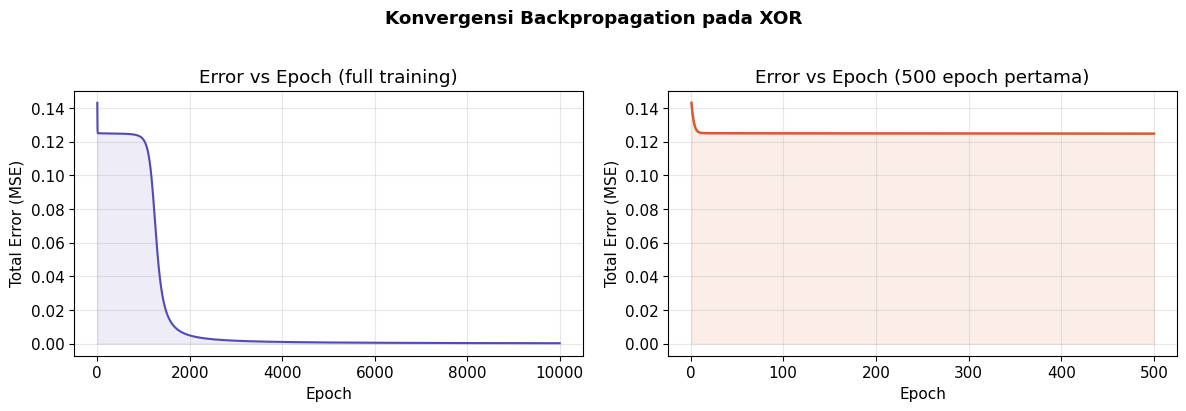

Error epoch 1    : 0.143150
Error epoch 1000 : 0.121260
Error epoch akhir: 0.000287

Penurunan error  : 99.8%


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history) + 1)

# ── Grafik kiri: full training ──────────────────────────────────────────
ax1.plot(epochs_range, history, color='#534AB7', linewidth=1.5)
ax1.set_title('Error vs Epoch (full training)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Total Error (MSE)')
ax1.grid(True, alpha=0.3)
ax1.fill_between(epochs_range, history, alpha=0.1, color='#534AB7')

# ── Grafik kanan: 500 epoch pertama (zoom in) ───────────────────────────
ax2.plot(list(epochs_range)[:500], history[:500], color='#D85A30', linewidth=1.8)
ax2.set_title('Error vs Epoch (500 epoch pertama)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Total Error (MSE)')
ax2.grid(True, alpha=0.3)
ax2.fill_between(list(epochs_range)[:500], history[:500], alpha=0.1, color='#D85A30')

plt.suptitle('Konvergensi Backpropagation pada XOR', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Error epoch 1    : {history[0]:.6f}")
print(f"Error epoch 1000 : {history[999]:.6f}")
print(f"Error epoch akhir: {history[-1]:.6f}")
print(f"\nPenurunan error  : {((history[0] - history[-1]) / history[0] * 100):.1f}%")

---

## 9. Evaluasi Model Terlatih

Setelah training selesai, model diuji menggunakan seluruh data XOR. Output prediksi dibandingkan dengan target asli untuk melihat apakah jaringan berhasil mempelajari pola XOR.


In [19]:
# Prediksi menggunakan bobot yang sudah dilatih
_, predictions = forward_pass(X, W1_trained, b1_trained, W2_trained, b2_trained)

print("=" * 55)
print("HASIL EVALUASI MODEL")
print("=" * 55)
print(f"\n{'X1':>4} {'X2':>4} {'Target':>8} {'Prediksi':>10} {'Dibulatkan':>12} {'Status':>8}")
print("-" * 55)

benar = 0
for i in range(len(X)):
    pred_raw   = predictions[i][0]
    pred_round = round(pred_raw)        # bulatkan ke 0 atau 1
    target_val = y[i][0]
    status     = "BENAR" if pred_round == target_val else "SALAH"
    if pred_round == target_val:
        benar += 1
    print(f"{X[i][0]:>4} {X[i][1]:>4} {target_val:>8} {pred_raw:>10.4f} {pred_round:>12} {status:>8}")

print("-" * 55)
akurasi = benar / len(X) * 100
print(f"\nAkurasi: {benar}/{len(X)} benar ({akurasi:.0f}%)")

if akurasi == 100:
    print("Model berhasil mempelajari semua pola XOR!")
else:
    print("Model belum sempurna — coba tambah epoch atau ubah learning rate.")

HASIL EVALUASI MODEL

  X1   X2   Target   Prediksi   Dibulatkan   Status
-------------------------------------------------------
   0    0        0     0.0230            0    BENAR
   0    1        1     0.9742            1    BENAR
   1    0        1     0.9742            1    BENAR
   1    1        0     0.0208            0    BENAR
-------------------------------------------------------

Akurasi: 4/4 benar (100%)
Model berhasil mempelajari semua pola XOR!


---

## 10. Bobot Akhir Setelah Training

Bagian ini menampilkan bobot dan bias final setelah proses training. Nilai inilah yang digunakan model untuk menghasilkan prediksi pada tahap evaluasi.


In [20]:
print("=" * 45)
print("BOBOT AKHIR SETELAH TRAINING")
print("=" * 45)

print(f"\nW1 — Input → Hidden:")
label_input  = ['X1', 'X2']
label_hidden = ['H1', 'H2']
for i, li in enumerate(label_input):
    for j, lh in enumerate(label_hidden):
        print(f"  w({li}→{lh}) = {W1_trained[i][j]:>8.4f}")

print(f"\nb1 — Bias Hidden:")
for j, lh in enumerate(label_hidden):
    print(f"  b({lh})    = {b1_trained[0][j]:>8.4f}")

print(f"\nW2 — Hidden → Output:")
for i, lh in enumerate(label_hidden):
    print(f"  w({lh}→Y)  = {W2_trained[i][0]:>8.4f}")

print(f"\nb2 — Bias Output:")
print(f"  b(Y)    = {b2_trained[0][0]:>8.4f}")

BOBOT AKHIR SETELAH TRAINING

W1 — Input → Hidden:
  w(X1→H1) =  -6.5154
  w(X1→H2) =   6.6988
  w(X2→H1) =   6.7095
  w(X2→H2) =  -6.4937

b1 — Bias Hidden:
  b(H1)    =   3.3000
  b(H2)    =   3.2855

W2 — Hidden → Output:
  w(H1→Y)  =  -8.2924
  w(H2→Y)  =  -8.2944

b2 — Bias Output:
  b(Y)    =  12.2450


---

## 11. Eksperimen: Pengaruh Learning Rate

Learning rate menentukan besar langkah pembaruan bobot pada setiap iterasi training.

- Learning rate terlalu kecil dapat membuat proses konvergensi menjadi lambat.
- Learning rate terlalu besar dapat membuat training tidak stabil atau sulit konvergen.

Eksperimen ini membandingkan beberapa nilai learning rate untuk melihat pengaruhnya terhadap proses pembelajaran model.


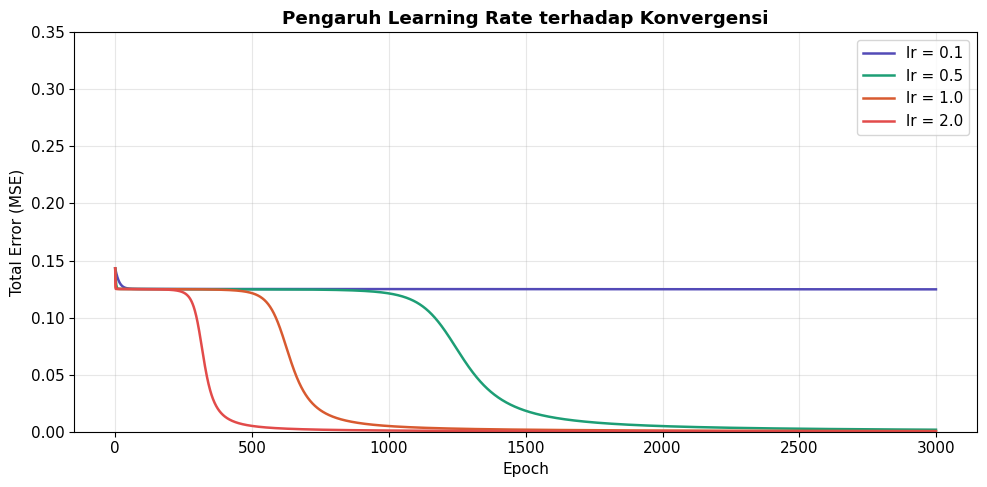

Kesimpulan:
  lr = 0.1  → konvergen lambat tapi stabil
  lr = 0.5  → keseimbangan baik (default)
  lr = 1.0  → lebih cepat, tapi bisa tidak stabil
  lr = 2.0  → terlalu besar, konvergensi terganggu


In [21]:
learning_rates = [0.1, 0.5, 1.0, 2.0]
colors = ['#534AB7', '#1D9E75', '#D85A30', '#E24B4A']

plt.figure(figsize=(10, 5))

for lr, color in zip(learning_rates, colors):
    np.random.seed(42)
    W1_e = np.random.uniform(-1, 1, (2, 2))
    b1_e = np.zeros((1, 2))
    W2_e = np.random.uniform(-1, 1, (2, 1))
    b2_e = np.zeros((1, 1))

    hist_e = []
    for _ in range(3000):
        out_H_e, out_Y_e = forward_pass(X, W1_e, b1_e, W2_e, b2_e)
        err_e = 0.5 * np.mean((y - out_Y_e) ** 2)
        hist_e.append(err_e)
        W1_e, b1_e, W2_e, b2_e = backward_pass(
            X, out_H_e, out_Y_e, y, W1_e, b1_e, W2_e, b2_e, lr
        )

    plt.plot(hist_e, label=f'lr = {lr}', color=color, linewidth=1.8)

plt.title('Pengaruh Learning Rate terhadap Konvergensi', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Total Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.35)
plt.tight_layout()
plt.show()

print("Kesimpulan:")
print("  lr = 0.1  → konvergen lambat tapi stabil")
print("  lr = 0.5  → keseimbangan baik (default)")
print("  lr = 1.0  → lebih cepat, tapi bisa tidak stabil")
print("  lr = 2.0  → terlalu besar, konvergensi terganggu")

---

## 12. Kesimpulan

Hal yang telah dibuktikan melalui notebook ini:

1. **XOR membutuhkan hidden layer** karena pola datanya tidak linearly separable.
2. **Backpropagation mampu menurunkan error** melalui proses update bobot secara iteratif.
3. **Model berhasil mempelajari pola XOR** setelah training dilakukan selama sejumlah epoch.
4. **Learning rate memengaruhi konvergensi** karena menentukan besar langkah pembaruan bobot.

### Alur Algoritma Backpropagation

<img src="images/flow.png" width="500" alt="Alur algoritma backpropagation">

```text
Untuk setiap epoch:
  1. Forward pass  -> hitung output tiap layer
  2. Hitung error  -> E = 1/2 * (target - output)^2
  3. Backward pass -> hitung delta output dan hidden
  4. Update bobot  -> W = W + learning_rate * input * delta
  5. Ulangi sampai error konvergen
```

### Rumus Kunci

<img src="images/rumus-loop.png" width="500" alt="Rumus utama backpropagation">
